## Analysis of the obtained results

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Analysis results zero-shot

In [15]:
from analysis_tools import (
    load_and_merge_profiles
    )

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_system/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive', 'profile31_passive', 'profile32_passive', 'profile33_passive', 'profile34_passive', 'profile35_passive', 'profile36_passive', 'profile37_passive', 'profile38_passive', 'profile39_passive', 'profile40_passive', 'profile41_p



=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 8
Statistical Significance Rate: 25.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -2.301 (Large)
 2. asian_vs_indian                     Effect Size: -2.203 (Large)
 3. black_vs_middle_eastern             Effect Size: -1.816 (Large)
 4. asian_vs_middle_eastern             Effect Size: -1.703 (Large)
 5. indian_vs_white                     Effect Size:  1.475 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.713 | Woman: 0.713
         Δ = -0.000 | p = 0.871 | d = -0.043
[NON-SIGNIFICANT]     asian_vs_black                      | Asian: 0.709 | Black: 0.708
         Δ = +0.001 | p = 0.660 | d = 0.211

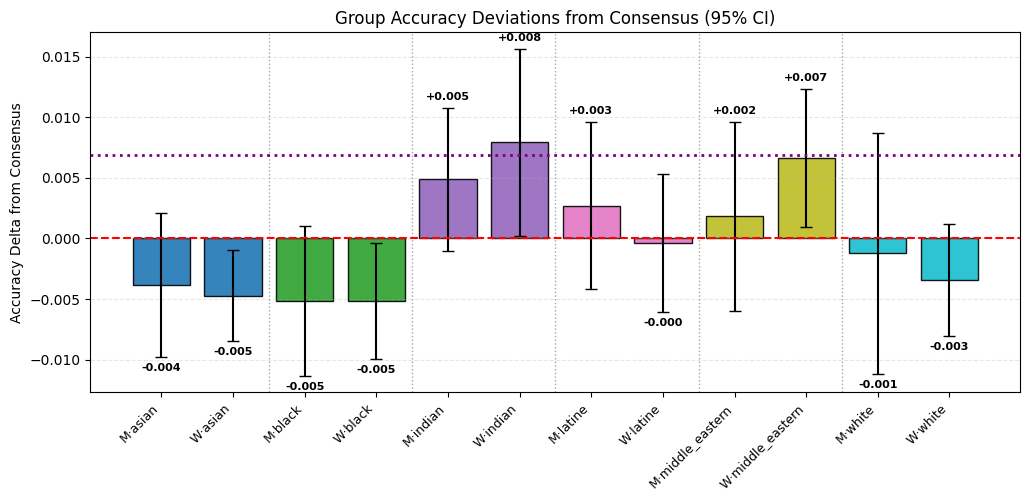

In [16]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS, PERSON_SYSTEMATIC

results = run_full_preliminary_analysis(merged_df, df=sample_mgsd, person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, df=sample_mgsd, person_set=PERSON_SYSTEMATIC)

In [ ]:
from profiles.profile_sets import PERSON_ETHNICS

#print(PROFILE_META_ETHNICS)
#print(PERSON_ETHNICS)

{'profile1': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>), 'profile2': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_2: 25>), 'profile3': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_3: 35>), 'profile4': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_4: 45>), 'profile5': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_5: 55>), 'profile6': PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>), 'profile7': PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_2: 25>), 'profile8': PersonMeta(gender=<Gender.woman: 'woman'>, ethni

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 65)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.726000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.713000  0.006275
woman      30  0.713267  0.006378

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7092  0.003795
black              10  0.7084  0.004195
indian             10  0.7190  0.005437
latine             10  0.7142  0.005029
middle_eastern     10  0.7170  0.005676
white              10  0.7110  0.005981

AGE:
     count      mean       std
age   

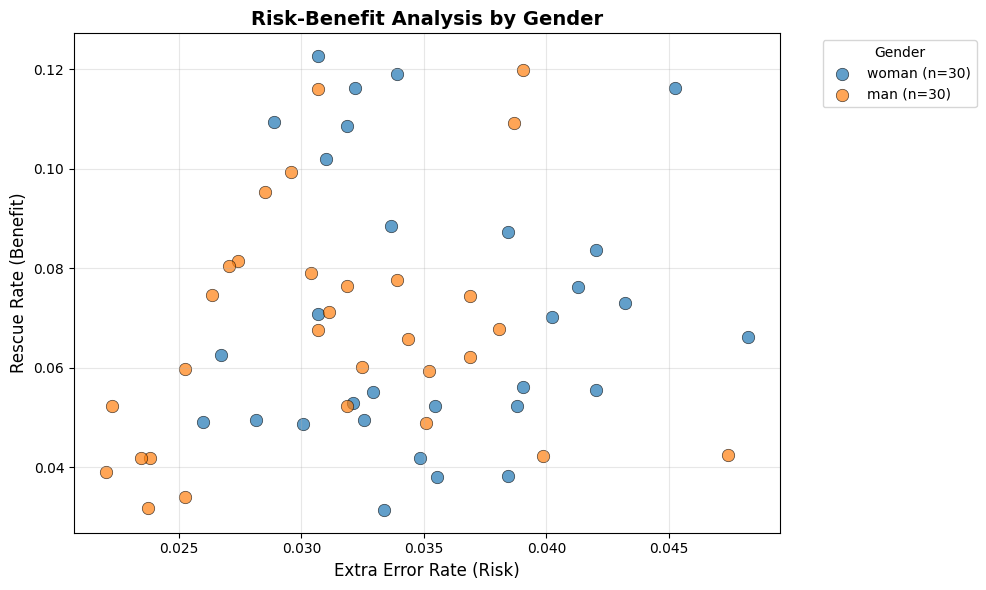


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


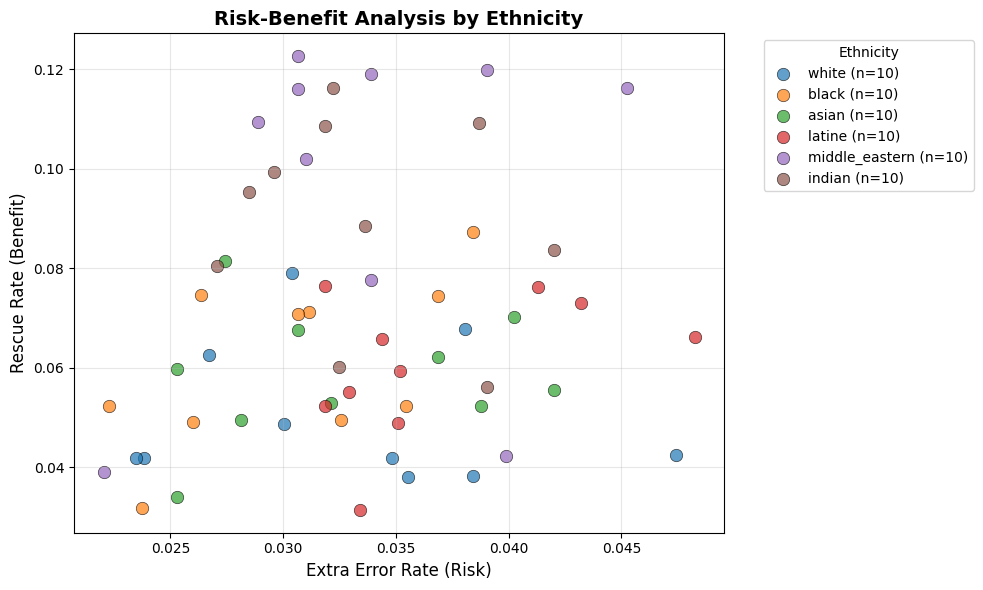


Creating risk-benefit plot for age...
  age levels: ['55', '20', '25', '35', '45']


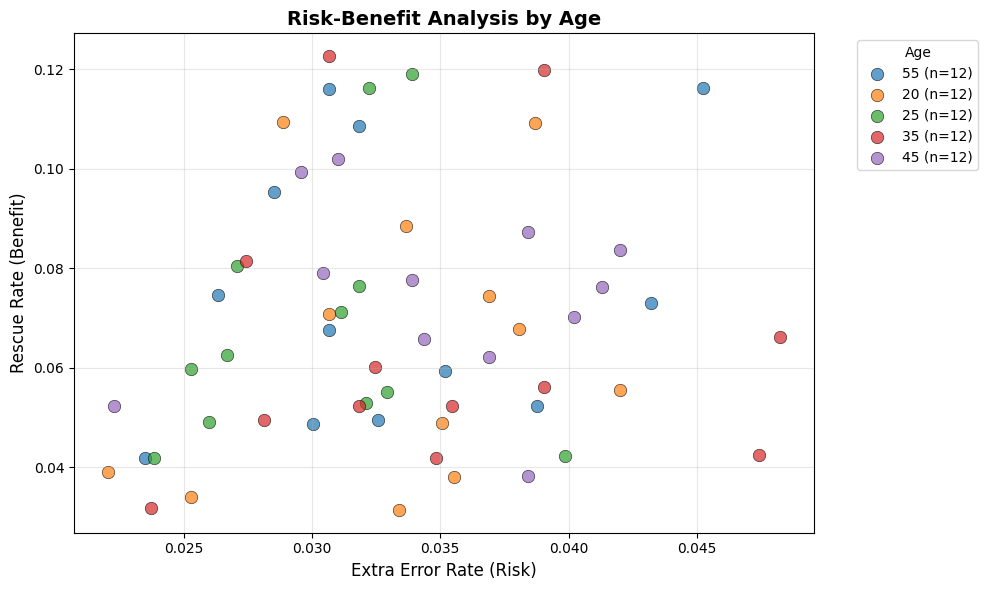


Creating Pareto frontier analysis...


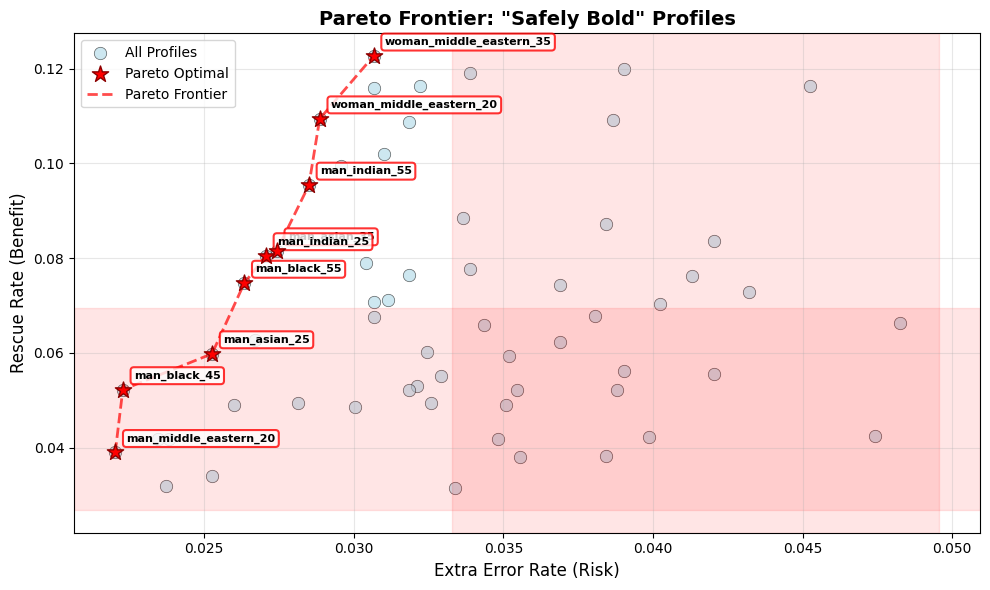


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (9 found):
  man_black_45 (profile14_passive)
    Rescue Rate: 0.052, Extra Error Rate: 0.022
    Total Rescued: 10, Total Extra Errors: 14
  man_black_55 (profile15_passive)
    Rescue Rate: 0.075, Extra Error Rate: 0.026
    Total Rescued: 10, Total Extra Errors: 14
  man_asian_25 (profile22_passive)
    Rescue Rate: 0.060, Extra Error Rate: 0.025
    Total Rescued: 11, Total Extra Errors: 13
  man_asian_35 (profile23_passive)
    Rescue Rate: 0.082, Extra Error Rate: 0.027
    Total Rescued: 10, Total Extra Errors: 14
  man_middle_eastern_20 (profile41_passive)
    Rescue Rate: 0.039, Extra Error Rate: 0.022
    Total Rescued: 9, Total Extra Errors: 11
  woman_middle_eastern_20 (profile46_passive)
    Rescue Rate: 0.109, Extra Error Rate: 0.029
    Total Rescued: 17, Total Extra Errors: 15
  woman_middle_eastern_35 (profile48_passive)
    Rescue Rate: 0.123, Extra Error Rate: 0.031
    Total Rescued: 18, Total Extra Errors: 

In [21]:
from analysis_1 import run_full_tier1_analysis

# "cognitive_style"
# "age"
#result_tier1 = run_full_tier1_analysis(merged_df,  group_keys=("gender", "ethnicity", "cognitive_style"),  person_set=PERSON_SYSTEMATIC)
result_tier1 = run_full_tier1_analysis(merged_df,  group_keys=("gender", "ethnicity", "age"),  person_set=PERSON_ETHNICS)

🚀 EXECUTING TIER 2 ANALYSIS PIPELINE

=== Running Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity', 'age')
Building trait groups with keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns
Created 60 trait groups:
  man_white_20: 1 profiles
  man_white_25: 1 profiles
  man_white_35: 1 profiles
  man_white_45: 1 profiles
  man_white_55: 1 profiles
  woman_white_20: 1 profiles
  woman_white_25: 1 profiles
  woman_white_35: 1 profiles
  woman_white_45: 1 profiles
  woman_white_55: 1 profiles
  man_black_20: 1 profiles
  man_black_25: 1 profiles
  man_black_35: 1 profiles
  man_black_45: 1 profiles
  man_black_55: 1 profiles
  woman_black_20: 1 profiles
  woman_black_25: 1 profiles
  woman_black_35: 1 profiles
  woman_black_45: 1 profiles
  woman_black_55: 1 profiles
  man_asian_20: 1 profiles
  man_asian_25: 1 profiles
  man_asian_35: 1 profiles
  man_asian_45: 1 profiles
  man_asian_55: 1 profiles
  woman_asian_20: 1 p

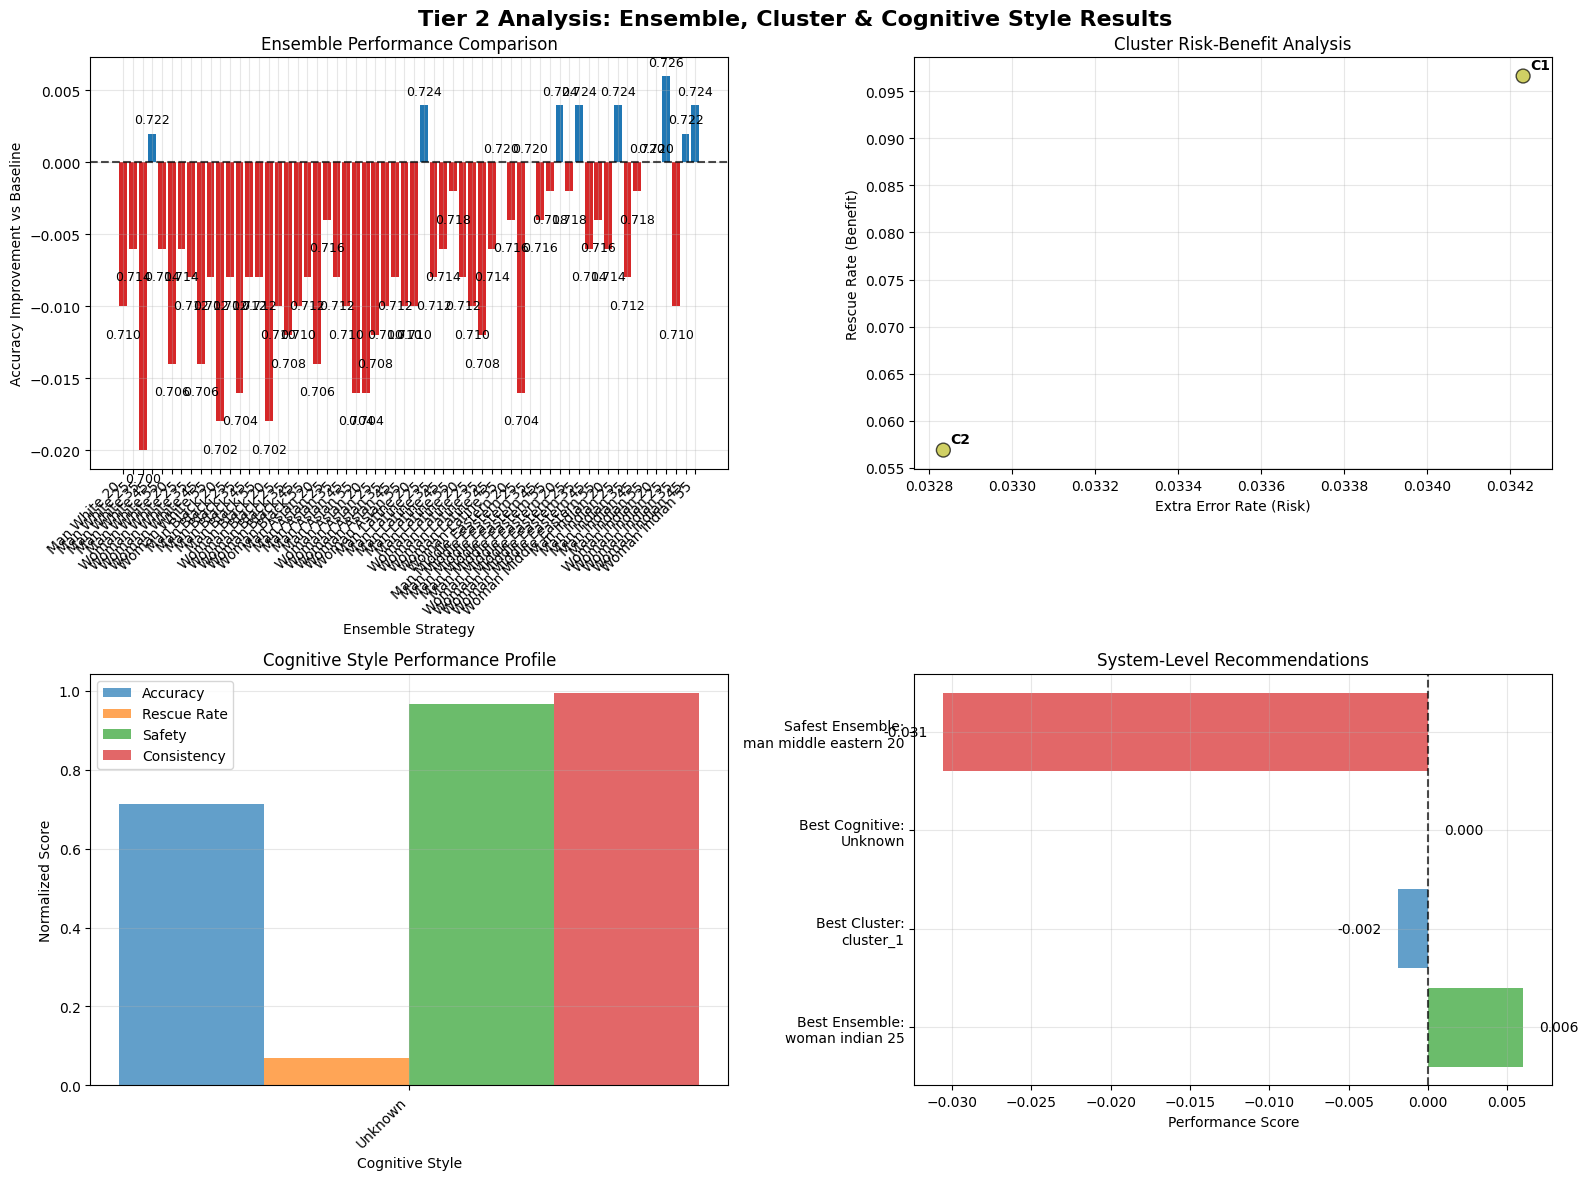


TIER 2 EXECUTIVE SUMMARY

=== KEY FINDINGS:
   • Best Ensemble Strategy: woman_indian_25
   • Best Cluster: cluster_1
   • Best Cognitive Style: Unknown

=== PERFORMANCE GAINS:
   • Best Ensemble Improvement: +0.0060
   • Safety-Performance Balance Achieved

=== SAFETY INSIGHTS:
   • Safest Strategy: man_middle_eastern_20
   • Minimum Extra Error Rate: 0.031


In [23]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_ETHNICS, group_keys=("gender", "ethnicity", "age"))
#result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC, group_keys=("gender", "ethnicity", "cognitive_style"))


🚀 EXECUTING TIER 3 ANALYSIS PIPELINE

 === Running Temporal Stability vs Boldness Analysis... === 
TEMPORAL STABILITY vs BOLDNESS TRADEOFF ANALYSIS
=== Calculating temporal stability across 5 folds...
=== Calculating boldness metrics...
=== Analyzing stability-boldness correlations...

--- CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.125, p=0.5100 
  Volatility vs Rescue Rate: r=-0.154, p=0.4158 
  Boldness vs Accuracy: r=0.381, p=0.0377 ***

=== PROFILE CLASSIFICATION:
  profile1 (gender=man, ethnicity=white, cognitive_style=expansive): Stable Bold – Best performance, low risk
  profile2 (gender=man, ethnicity=white, cognitive_style=literal): Stable Bold – Best performance, low risk
  profile3 (gender=man, ethnicity=white, cognitive_style=high_harm): Volatile Bold – High risk, high moral value
  profile4 (gender=man, ethnicity=white, cognitive_style=low_harm): Volatile Cautious – High risk, low moral value
  profile5 (gender=man, ethnicity=white, cognitive_style=balanced): Vola

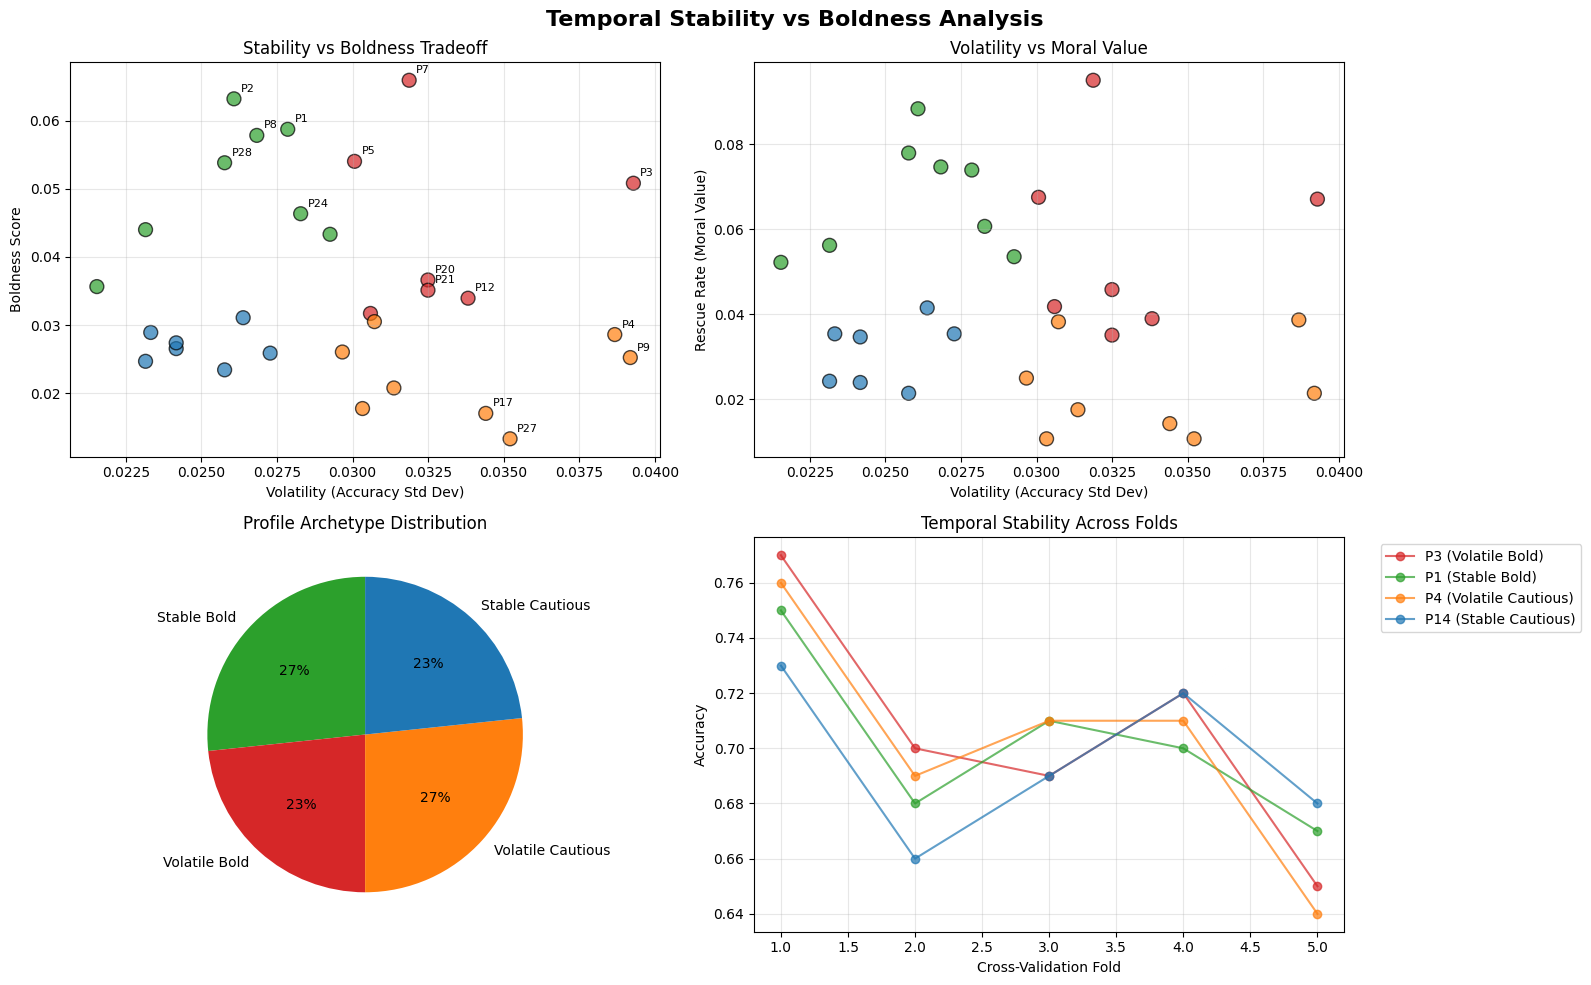


 === Creating Causal Model Visualizations... ===


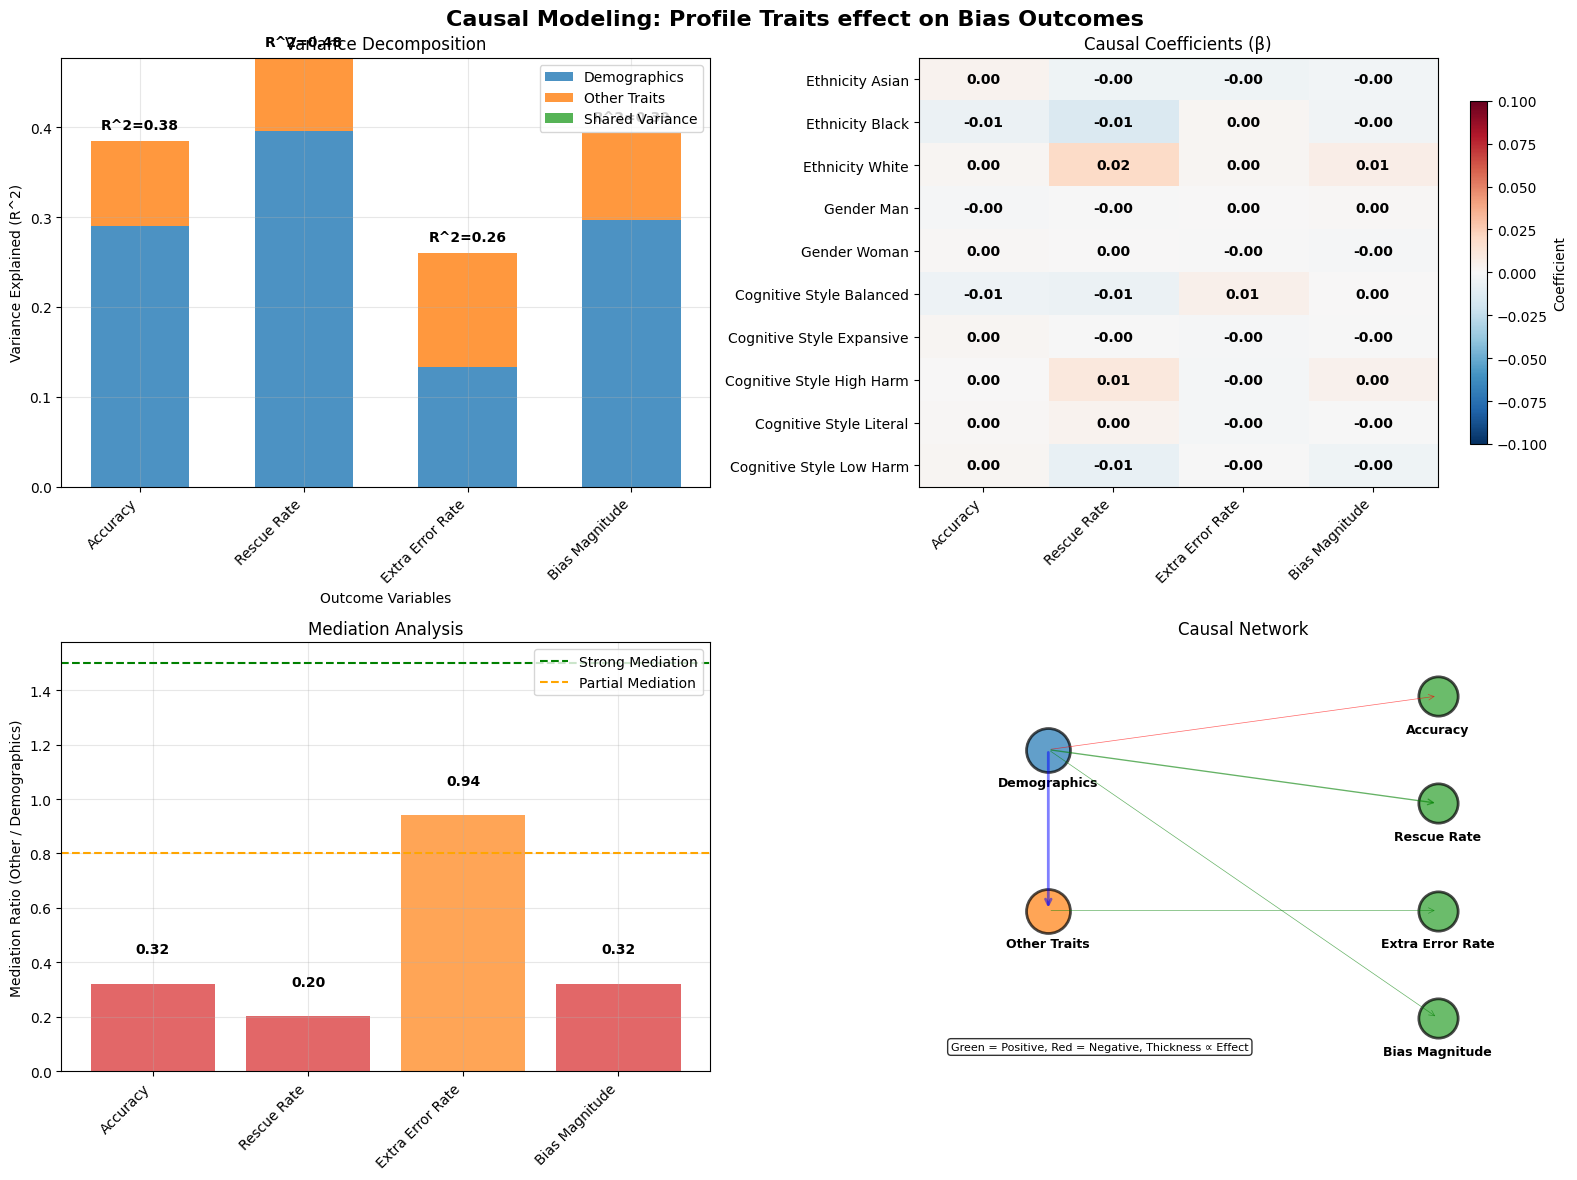


TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - --- Stable profiles outperform volatile ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Strongest predictor of moral value (rescue): ethnicity_white
   - Strongest predictor of performance (accuracy): ethnicity_black
   - Mediation effects found: extra_error_rate: Partial mediation

THESIS-LEVEL CONCLUSIONS

=== CONCLUSION 1: Demographics remain primary drivers of bias
   Evidence: Demographic factors dominate in 4/4 outcomes
   Implication: Diverse demographic representation is crucial for bias mitigation

=== CONCLUSION 2: ethnicity_white is the most critical trait for system design
   Evidence: Appears in 2/3 optimization objectives
   Implication: Systems should prioritize profiles with ethnicity_white characteristics


In [22]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

## Analysis of Few-shots role playing

In [50]:
from analysis_tools import (
    load_and_merge_profiles
    )
merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_system/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'original_dataset', 'profile1_passive', 'profile2_passive', 'profile3_passive', 'profile4_passive', 'profile5_passive', 'profile6_passive', 'profile7_passive', 'profile8_passive', 'profile9_passive', 'profile10_passive', 'profile11_passive', 'profile12_passive', 'profile13_passive', 'profile14_passive', 'profile15_passive', 'profile16_passive', 'profile17_passive', 'profile18_passive', 'profile19_passive', 'profile20_passive', 'profile21_passive', 'profile22_passive', 'profile23_passive', 'profile24_passive', 'profile25_passive', 'profile26_passive', 'profile27_passive', 'profile28_passive', 'profile29_passive', 'profile30_passive', 'profile31_passive', 'profile32_passive', 'profile33_passive', 'profile34_passive', 'profile35_passive', 'profile36_passive', 'profile37_passive', 'profile38_passive', 'profile39_passive', 'profile40_passive', 'profile41_p



=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -3.180 (Large)
 2. indian_vs_latine                    Effect Size:  2.567 (Large)
 3. indian_vs_white                     Effect Size:  1.903 (Large)
 4. asian_vs_indian                     Effect Size: -1.859 (Large)
 5. black_vs_middle_eastern             Effect Size: -1.395 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.716 | Woman: 0.714
         Δ = +0.003 | p = 0.161 | d = 0.373
[SIGNIFICANT] asian_vs_black                      | Asian: 0.715 | Black: 0.709
         Δ = +0.005 | p = 0.022 | d = 1.181
[SIGNIFI

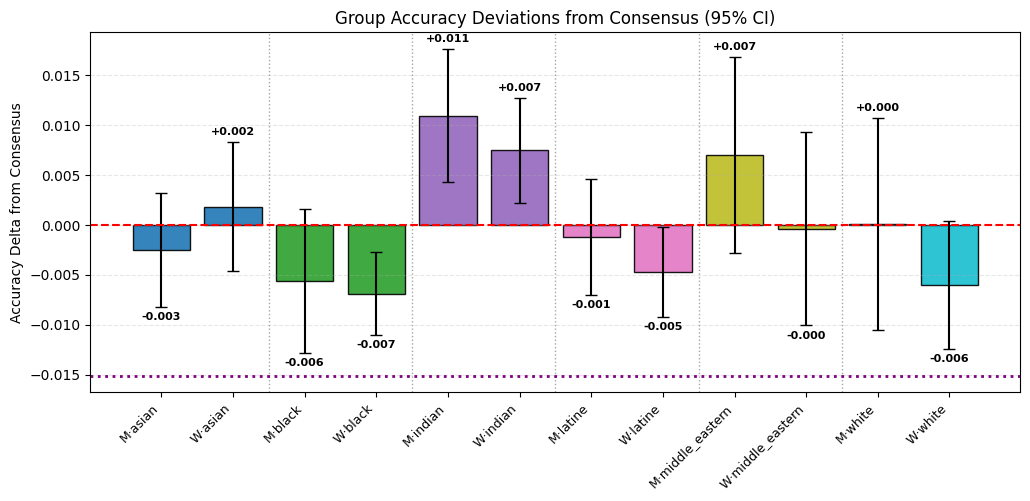

In [51]:
from analysis_0 import *

results = run_full_preliminary_analysis(merged_df, df = sample_mgsd, person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, df = sample_mgsd, person_set=PERSON_SYSTEMATIC)


Running factorial ANOVA on profile traits...


FACTORIAL ANOVA: ACCURACY
GENDER MAIN EFFECT:
  man mean: 0.7127
  woman mean: 0.7117
  Unknown mean: 0.7181
  F-statistic: 5.610
  p-value: 0.0060 ***
ETHNICITY MAIN EFFECT:
  white mean: 0.7124
  black mean: 0.7094
  asian mean: 0.7148
  Unknown mean: 0.7181
  F-statistic: 4.916
  p-value: 0.0042 ***
COGNITIVE_STYLE MAIN EFFECT:
  expansive mean: 0.7177
  literal mean: 0.7110
  high_harm mean: 0.7117
  low_harm mean: 0.7100
  balanced mean: 0.7107
  Unknown mean: 0.7181
  F-statistic: 3.329
  p-value: 0.0108 ***

INTERACTION EFFECTS (gender x ethnicity):
  man x white: 0.7152
  man x black: 0.7100
  man x asian: 0.7128
  woman x white: 0.7096
  woman x black: 0.7088
  woman x asian: 0.7168
  Unknown x Unknown: 0.7181
  → OLS p-value for gender x ethnicity: 0.0163

FACTORIAL ANOVA: RESCUE_RATE
GENDER MAIN EFFECT:
  man mean: 0.0863
  woman mean: 0.0807
  Unknown mean: 0.1036
  F-statistic: 9.115
  p-value: 0.0004 ***
ETHNICITY MAIN EFFEC

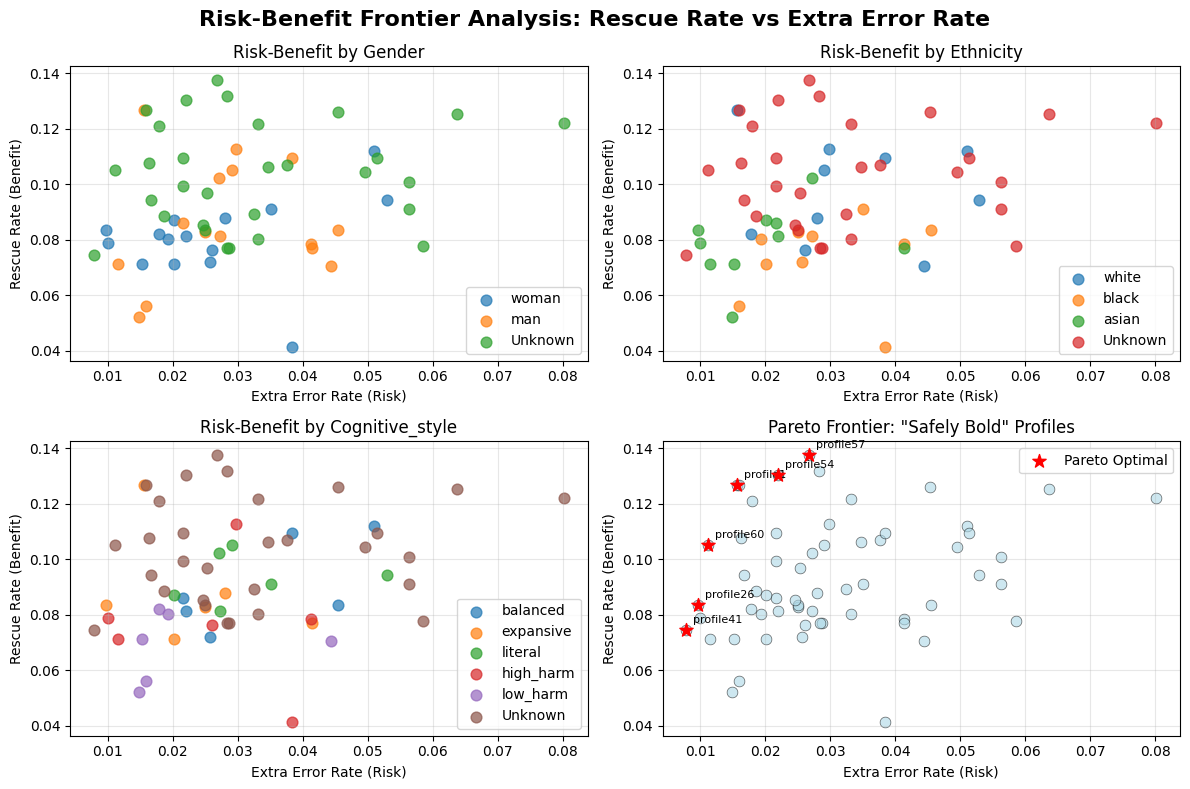


PARETO FRONTIER ANALYSIS

Pareto Optimal Profiles (Safely Bold):
  profile1_passive: gender: man, ethnicity: white, cognitive_style: expansive
    Rescue Rate: 0.127, Extra Error Rate: 0.016
  profile26_passive: gender: woman, ethnicity: asian, cognitive_style: expansive
    Rescue Rate: 0.084, Extra Error Rate: 0.010
  profile41_passive: gender: Unknown, ethnicity: Unknown, cognitive_style: Unknown
    Rescue Rate: 0.074, Extra Error Rate: 0.008
  profile54_passive: gender: Unknown, ethnicity: Unknown, cognitive_style: Unknown
    Rescue Rate: 0.130, Extra Error Rate: 0.022
  profile57_passive: gender: Unknown, ethnicity: Unknown, cognitive_style: Unknown
    Rescue Rate: 0.138, Extra Error Rate: 0.027
  profile60_passive: gender: Unknown, ethnicity: Unknown, cognitive_style: Unknown
    Rescue Rate: 0.105, Extra Error Rate: 0.011

Risk-Benefit Statistics:
  Average rescue rate: 0.094
  Average extra error rate: 0.030
  Best rescue rate: 0.138
  Lowest extra error rate: 0.008

Profil

In [7]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df)

🚀 EXECUTING TIER 2 ANALYSIS PIPELINE

=== Running Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS
Baseline accuracy: 0.7000

Ensemble Performance by Trait Group:
--------------------------------------------------
man white expansive      : 0.7300 (+0.0300) | Rescue: 0.167 | Extra Err: 0.029 | n=1
man white literal        : 0.7120 (+0.0120) | Rescue: 0.140 | Extra Err: 0.043 | n=1
man white high_harm      : 0.7140 (+0.0140) | Rescue: 0.147 | Extra Err: 0.043 | n=1
man white low_harm       : 0.7080 (+0.0080) | Rescue: 0.093 | Extra Err: 0.029 | n=1
man white balanced       : 0.7120 (+0.0120) | Rescue: 0.153 | Extra Err: 0.049 | n=1
woman white expansive    : 0.7100 (+0.0100) | Rescue: 0.107 | Extra Err: 0.031 | n=1
woman white literal      : 0.7080 (+0.0080) | Rescue: 0.127 | Extra Err: 0.043 | n=1
woman white high_harm    : 0.7020 (+0.0020) | Rescue: 0.093 | Extra Err: 0.037 | n=1
woman white low_harm     : 0.7120 (+0.0120) | Rescue: 0.113 | Extra Err: 0.031 | n=1
woman white b

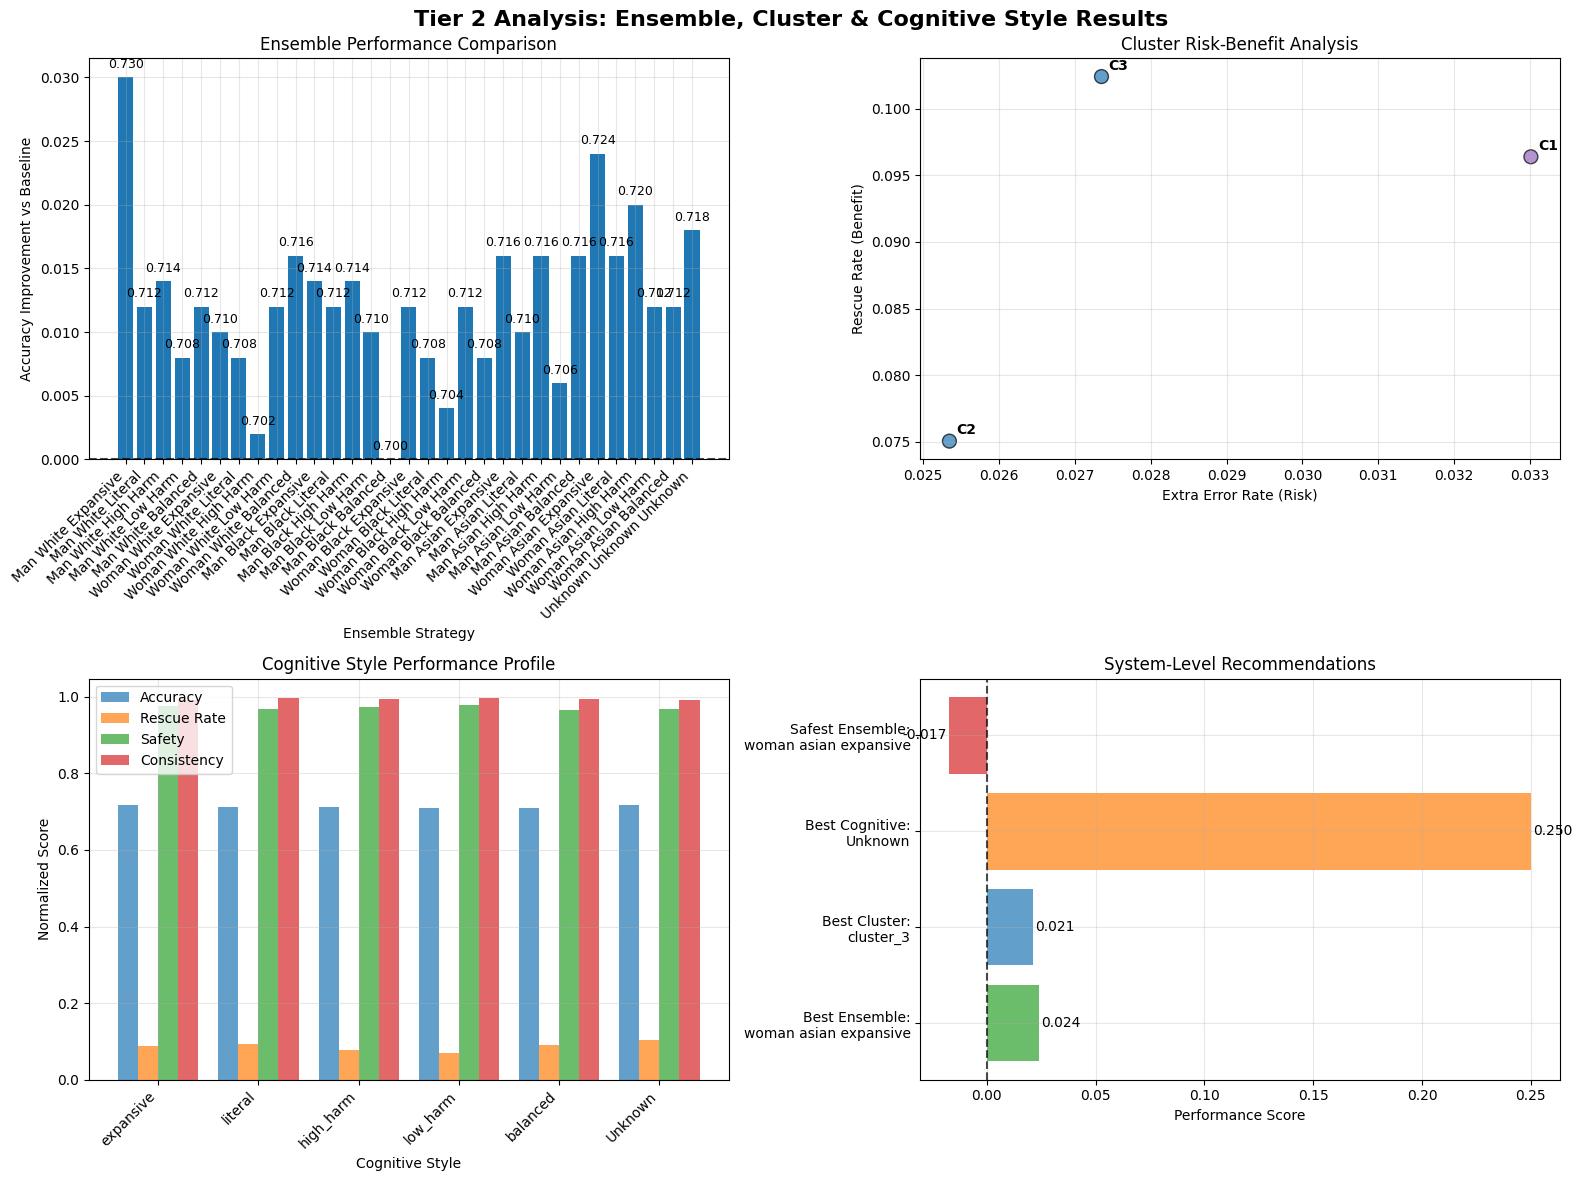


TIER 2 EXECUTIVE SUMMARY

=== KEY FINDINGS:
   • Best Ensemble Strategy: woman asian expansive
   • Best Cluster: cluster_3
   • Best Cognitive Style: Unknown

=== PERFORMANCE GAINS:
   • Best Ensemble Improvement: +0.0240
   • Safety-Performance Balance Achieved

=== SAFETY INSIGHTS:
   • Safest Strategy: woman asian expansive
   • Minimum Extra Error Rate: 0.017


In [8]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

🚀 EXECUTING TIER 3 ANALYSIS PIPELINE

 === Running Temporal Stability vs Boldness Analysis... === 
TEMPORAL STABILITY vs BOLDNESS TRADEOFF ANALYSIS
=== Calculating temporal stability across 5 folds...
=== Calculating boldness metrics...
=== Analyzing stability-boldness correlations...

--- CORRELATION RESULTS:
  Volatility vs Boldness: r=0.174, p=0.3591 
  Volatility vs Rescue Rate: r=0.059, p=0.7553 
  Boldness vs Accuracy: r=0.231, p=0.2191 

=== PROFILE CLASSIFICATION:
  profile1 (gender=man, ethnicity=white, cognitive_style=expansive): Volatile Bold – High risk, high moral value
  profile2 (gender=man, ethnicity=white, cognitive_style=literal): Volatile Bold – High risk, high moral value
  profile3 (gender=man, ethnicity=white, cognitive_style=high_harm): Volatile Bold – High risk, high moral value
  profile4 (gender=man, ethnicity=white, cognitive_style=low_harm): Stable Cautious – Low risk, predictable
  profile5 (gender=man, ethnicity=white, cognitive_style=balanced): Volatile B

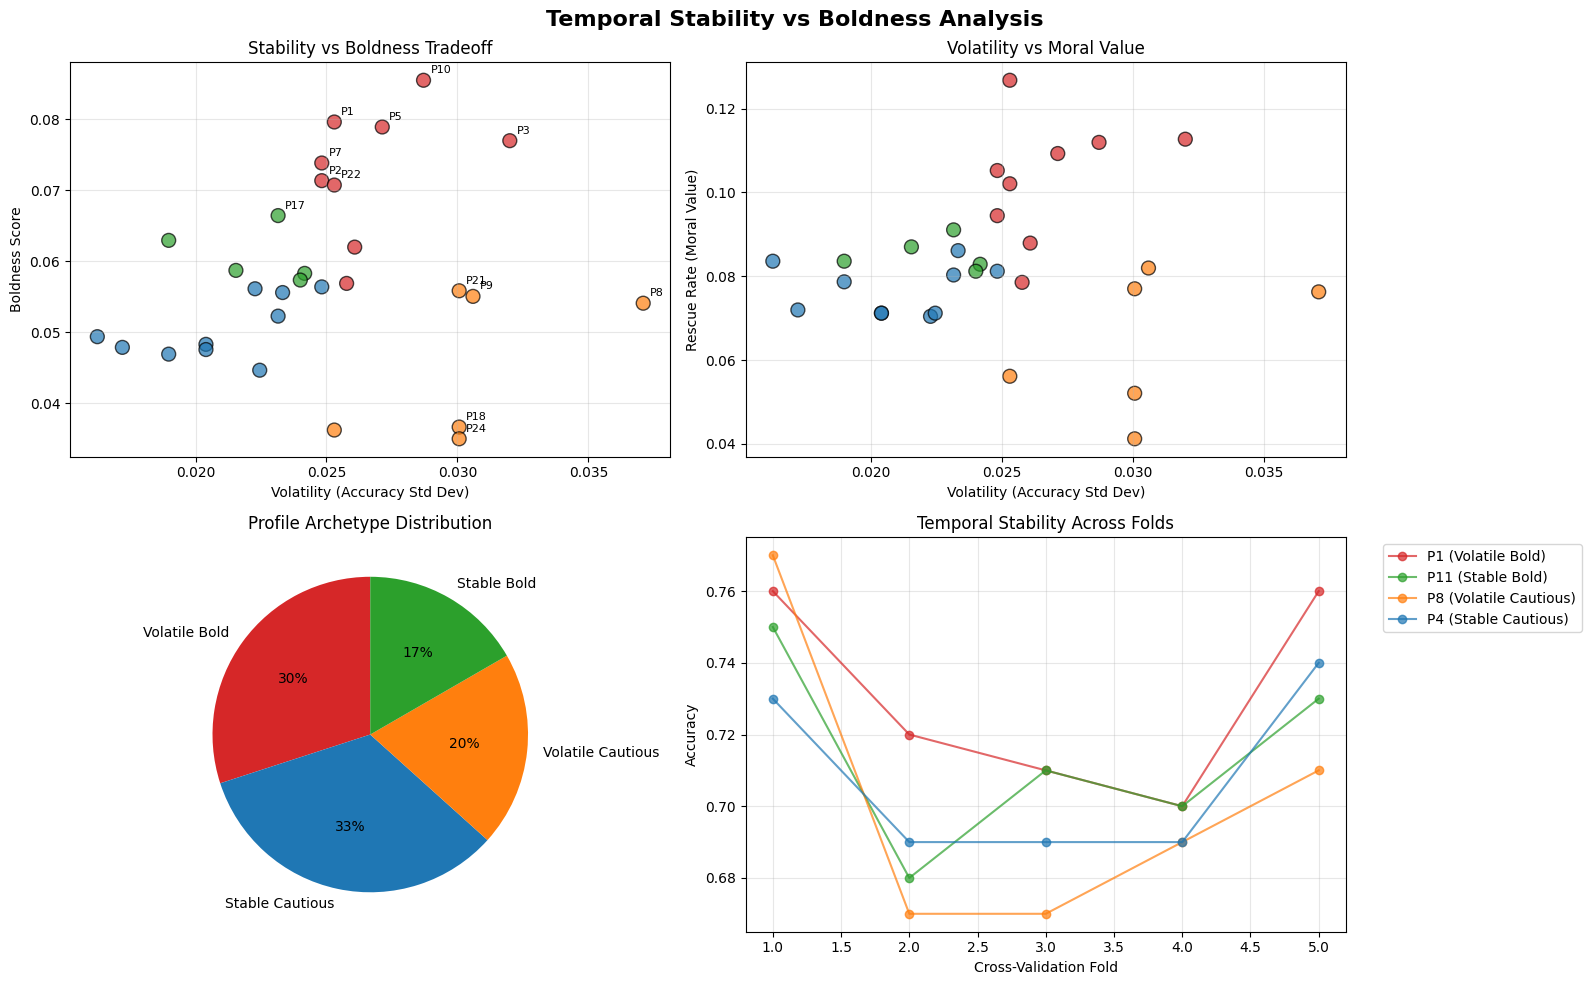


 === Creating Causal Model Visualizations... ===


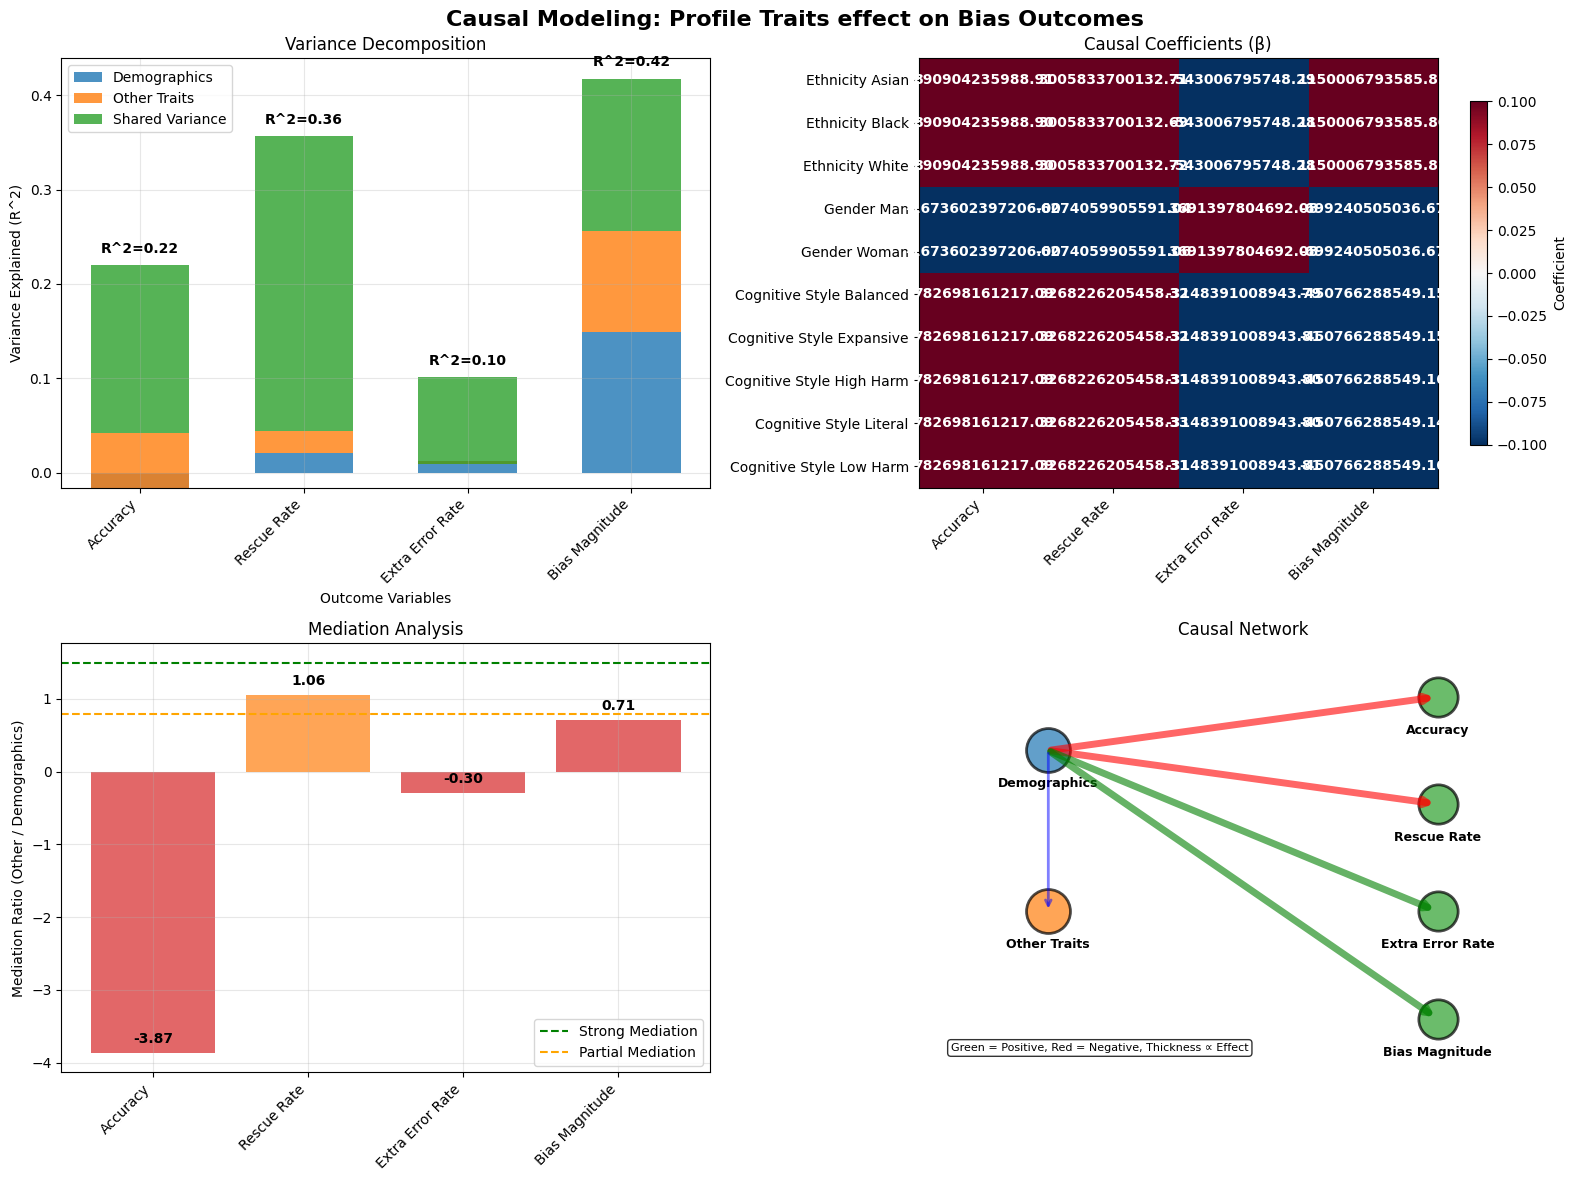


TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - --- Volatile profiles provide higher moral value through increased rescue rates
   - Implication: Risk-taking in AI annotation may be normatively justified
   - Strongest predictor of moral value (rescue): gender_woman
   - Strongest predictor of performance (accuracy): gender_woman
   - Mediation effects found: rescue_rate: Partial mediation

THESIS-LEVEL CONCLUSIONS

=== CONCLUSION 1: Demographics remain primary drivers of bias
   Evidence: Demographic factors dominate in 2/4 outcomes
   Implication: Diverse demographic representation is crucial for bias mitigation

=== CONCLUSION 2: cognitive_style_expansive is the most critical trait for system design
   Evidence: Appears in 2/3 optimization objectives
   Implication: Systems should prioritize profiles with cognitive_style_expansive characteristics


In [9]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

## Manipulation detection